In [2]:
!pip install -q librosa==0.10.1 scipy tqdm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 20.9 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
tf.__version__


'2.19.0'

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [5]:
import os, glob
PROJECT_FOLDER = 'ADHD_project'
BASE = f'/content/drive/MyDrive/{PROJECT_FOLDER}/data'
ADHD_DIR = os.path.join(BASE, 'ADHD')
CTRL_DIR = os.path.join(BASE, 'Control')

def list_mat_info(d):
    files = sorted(glob.glob(os.path.join(d, '*.mat')))
    print(f'Path: {d}')
    print(f'Found {len(files)} .mat files')
    for i, p in enumerate(files[:10]):
        sz = os.path.getsize(p)
        print(f'  {i+1:02d}. {os.path.basename(p)}  — {sz//1024} KB')
    if len(files) > 10:
        print('  ...')

list_mat_info(ADHD_DIR)
list_mat_info(CTRL_DIR)

if not os.path.isdir(ADHD_DIR):
    print("Warning: ADHD directory not found. Check path.")
if not os.path.isdir(CTRL_DIR):
    print("Warning: Control directory not found. Check path.")


Path: /content/drive/MyDrive/ADHD_project/data/ADHD
Found 61 .mat files
  01. v10p.mat  — 291 KB
  02. v12p.mat  — 276 KB
  03. v14p.mat  — 285 KB
  04. v15p.mat  — 602 KB
  05. v173.mat  — 277 KB
  06. v177.mat  — 330 KB
  07. v179.mat  — 227 KB
  08. v181.mat  — 114 KB
  09. v183.mat  — 215 KB
  10. v18p.mat  — 341 KB
  ...
Path: /content/drive/MyDrive/ADHD_project/data/Control
Found 60 .mat files
  01. v107.mat  — 281 KB
  02. v108.mat  — 232 KB
  03. v109.mat  — 275 KB
  04. v110.mat  — 363 KB
  05. v111.mat  — 322 KB
  06. v112.mat  — 190 KB
  07. v113.mat  — 210 KB
  08. v114.mat  — 237 KB
  09. v115.mat  — 222 KB
  10. v116.mat  — 265 KB
  ...


In [6]:
from scipy.io import loadmat
import numpy as np, pprint

sample_path = sorted(glob.glob(os.path.join(ADHD_DIR, '*.mat')))[0]
print('Inspecting:', sample_path)
m = loadmat(sample_path)

for k, v in m.items():
    if k.startswith('__'):
        continue
    if isinstance(v, np.ndarray):
        print(f'{k} : shape={getattr(v,"shape",None)} dtype={getattr(v,"dtype",None)}')
    else:
        print(f'{k} : type={type(v)}')

arrays = [v for v in m.values() if isinstance(v, np.ndarray) and v.ndim == 2]
if arrays:
    arr = max(arrays, key=lambda x: x.size)
    print('Largest 2D array shape:', arr.shape)
else:
    print('No 2D arrays found in this file.')


Inspecting: /content/drive/MyDrive/ADHD_project/data/ADHD/v10p.mat
v10p : shape=(14304, 19) dtype=float64
Largest 2D array shape: (14304, 19)


In [14]:
import numpy as np
import librosa
from scipy.io import loadmat

# --- Config (tweak if necessary) ---
SAMPLE_RATE = 128     # expected; change if your data differs
NUM_CHANNELS = 19
SEG_SECS = 4
SEG_SAMPLES = SEG_SECS * SAMPLE_RATE
OVERLAP = 0.5         # 50% overlap
N_MELS = 96
N_FFT = 256
HOP = 128

# --- helpers ---
def read_eeg_mat(path, num_channels=NUM_CHANNELS):
    d = loadmat(path)
    # choose largest 2D numeric array
    cand = [v for v in d.values() if isinstance(v, np.ndarray) and v.ndim == 2 and v.size > 100]
    if not cand:
        raise ValueError('No 2D array found.')
    arr = max(cand, key=lambda x: x.size)
    # orient to (channels, samples)
    if arr.shape[0] == num_channels:
        return arr.astype(np.float32)
    if arr.shape[1] == num_channels:
        return arr.T.astype(np.float32)
    # fallback: choose orientation closest to num_channels
    if abs(arr.shape[0]-num_channels) < abs(arr.shape[1]-num_channels):
        return arr.astype(np.float32)
    return arr.T.astype(np.float32)

def segment_signal(eeg, seg_len=SEG_SAMPLES, overlap=OVERLAP):
    step = int(seg_len * (1-overlap))
    total = eeg.shape[1]
    segs = []
    for start in range(0, total - seg_len + 1, step):
        s = eeg[:, start:start+seg_len]
        if s.shape[1] == seg_len:
            segs.append(s)
    return segs

def compute_log_mel(y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP):
    S = librosa.feature.melspectrogram(y=y.astype(np.float32), sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    logS = librosa.power_to_db(S, ref=np.max)
    return logS  # shape (n_mels, time_frames)

def segment_to_channel_specs(segment):
    """
    segment: (channels, seg_samples)
    returns: numpy array shape (channels, n_mels, time_frames)
    """
    ch_specs = []
    for ch in range(segment.shape[0]):
        spec = compute_log_mel(segment[ch, :])
        ch_specs.append(spec)
    # pad/crop to same time frames
    max_t = max(s.shape[1] for s in ch_specs)
    arr = np.zeros((segment.shape[0], N_MELS, max_t), dtype=np.float32)
    for i, s in enumerate(ch_specs):
        t = s.shape[1]
        arr[i, :, :t] = s[:, :max_t]
    return arr


Total segments in file: 54


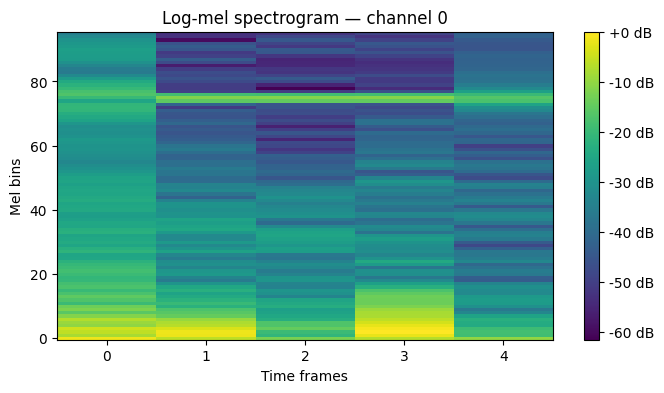

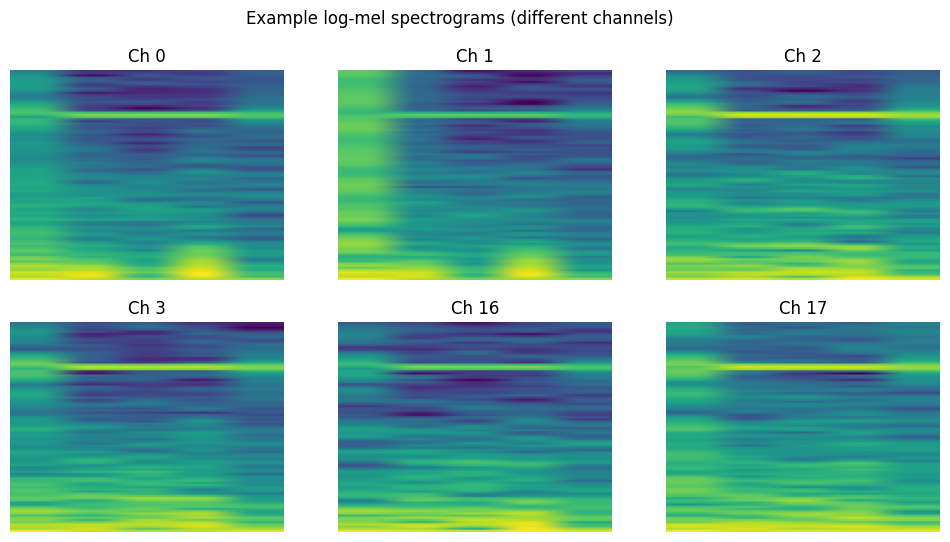

In [15]:
import matplotlib.pyplot as plt
import random

# pick a random file and segment
path = sorted(glob.glob(os.path.join(ADHD_DIR, '*.mat')))[0]
eeg = read_eeg_mat(path)
segs = segment_signal(eeg)
print('Total segments in file:', len(segs))
segment = segs[0]  # first segment (channels x seg_samples)
specs = segment_to_channel_specs(segment)  # (channels, n_mels, t)

# Plot a single channel's spectrogram (e.g., channel 0)
plt.figure(figsize=(8,4))
plt.title('Log-mel spectrogram — channel 0')
plt.imshow(specs[0], aspect='auto', origin='lower')
plt.xlabel('Time frames')
plt.ylabel('Mel bins')
plt.colorbar(format='%+2.0f dB')
plt.show()

# Plot a small grid of 6 channels
fig, axs = plt.subplots(2,3, figsize=(12,6))
ch_idx = [0,1,2,3,16,17]  # example channels (adjust if you want)
for ax, ci in zip(axs.ravel(), ch_idx):
    ax.set_title(f'Ch {ci}')
    ax.imshow(specs[ci], aspect='auto', origin='lower')
    ax.axis('off')
plt.suptitle('Example log-mel spectrograms (different channels)')
plt.show()


In [16]:
import random
import numpy as np
import glob
from tqdm import tqdm
import os

# CONFIG
MAX_SEGMENTS_PER_FILE = 20        # Increase for better accuracy
OVERLAP = 0.5
NOISE_PROB = 0.3                  # 30% chance of augmentation
NOISE_STD = 0.003                 # Standard deviation of Gaussian noise

def build_dataset(ad_dir=ADHD_DIR, ctrl_dir=CTRL_DIR, max_per_file=MAX_SEGMENTS_PER_FILE):
    X, y = [], []
    files = []

    print("Building dataset with noise augmentation...")

    # ------------ ADHD FILES (label=1) -------------
    for p in tqdm(sorted(glob.glob(os.path.join(ad_dir, '*.mat'))), desc="ADHD Files"):
        try:
            eeg = read_eeg_mat_auto(p)[0]      # <-- YOU ALREADY HAVE THIS FUNCTION
            segs = segment_signal(eeg, overlap=OVERLAP)

            if not segs:
                continue

            # Limit segments for memory safety
            if len(segs) > max_per_file:
                segs = random.sample(segs, max_per_file)

            for seg in segs:

                # ----------------------------------------
                # ⭐ NOISE AUGMENTATION (for training only)
                # ----------------------------------------
                if random.random() < NOISE_PROB:
                    noise = np.random.normal(0, NOISE_STD, seg.shape).astype(np.float32)
                    seg = seg + noise

                # Create log-mel specs for ALL channels
                arr = segment_to_channel_specs(seg)      # shape (channels, n_mels, time)

                # Add channel-last dim for Conv2D: (C, M, T, 1)
                X.append(arr[..., np.newaxis])
                y.append(1)
                files.append(p)

        except Exception as e:
            print("Skipping:", p, "Error:", e)

    # ------------ CONTROL FILES (label=0) -------------
    for p in tqdm(sorted(glob.glob(os.path.join(ctrl_dir, '*.mat'))), desc="Control Files"):
        try:
            eeg = read_eeg_mat_auto(p)[0]
            segs = segment_signal(eeg, overlap=OVERLAP)

            if not segs:
                continue

            if len(segs) > max_per_file:
                segs = random.sample(segs, max_per_file)

            for seg in segs:

                # ----------------------------------------
                # ⭐ NOISE AUGMENTATION (for training only)
                # ----------------------------------------
                if random.random() < NOISE_PROB:
                    noise = np.random.normal(0, NOISE_STD, seg.shape).astype(np.float32)
                    seg = seg + noise

                arr = segment_to_channel_specs(seg)
                X.append(arr[..., np.newaxis])
                y.append(0)
                files.append(p)

        except Exception as e:
            print("Skipping:", p, "Error:", e)

    # Convert lists to numpy arrays
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    print("Dataset Built Successfully!")
    print("X shape:", X.shape)  # (N, channels, n_mels, time, 1)
    print("y shape:", y.shape)

    return X, y, files


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(X_train.shape, X_val.shape, X_test.shape)


(726, 19, 64, 5, 1) (121, 19, 64, 5, 1) (121, 19, 64, 5, 1)


In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

EMBED_DIM = 256
NUM_HEADS = 4
TRANSFORMER_UNITS = 256
TRANSFORMER_LAYERS = 2
NUM_CHANNELS = X.shape[1]
N_MELS = X.shape[2]

def build_shared_cnn_encoder(input_shape=(N_MELS, None, 1), embed_dim=EMBED_DIM):
    inp = layers.Input(shape=input_shape)
    x = inp
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(embed_dim)(x)
    x = layers.LayerNormalization()(x)
    return models.Model(inputs=inp, outputs=x)


def build_cross_channel_attention_model(n_channels=NUM_CHANNELS, n_mels=N_MELS, embed_dim=EMBED_DIM):
    multi_input = layers.Input(shape=(n_channels, n_mels, None, 1), name='multi_channel_input')
    shared_encoder = build_shared_cnn_encoder(input_shape=(n_mels, None, 1), embed_dim=embed_dim)


    x = layers.TimeDistributed(shared_encoder)(multi_input)


    pos_emb = layers.Embedding(input_dim=n_channels, output_dim=embed_dim)
    channel_indices = tf.range(start=0, limit=n_channels, delta=1)
    def add_pos(inputs):
        batch = tf.shape(inputs)[0]
        pos = tf.expand_dims(pos_emb(channel_indices), axis=0)
        pos = tf.tile(pos, [batch, 1, 1])
        return inputs + pos
    x = layers.Lambda(add_pos)(x)


    for _ in range(TRANSFORMER_LAYERS):
        attn = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=embed_dim//NUM_HEADS)(x, x)
        attn = layers.Dropout(0.2)(attn)
        x = layers.LayerNormalization()(x + attn)
        ff = layers.Dense(TRANSFORMER_UNITS, activation='relu')(x)
        ff = layers.Dense(embed_dim)(ff)
        x = layers.LayerNormalization()(x + ff)

    x = layers.GlobalAveragePooling1D()(x)  # pool across channels
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=multi_input, outputs=out, name='CrossChannelAttention')
    return model

model = build_cross_channel_attention_model()
model.summary()


Model: "CrossChannelAttention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ multi_channel_input │ (None, 19, 64,    │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 19, 256)   │    437,760 │ multi_channel_in… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 19, 256)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 19, 256)   │    263,168 │ lambda_2[0][0],   │
│ (MultiHeadAttentio… │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 19, 256)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 19, 256)   │          0 │ lambda_2[0][0],   │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 19, 256)   │        512 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 19, 256)   │     65,792 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 19, 256)   │     65,792 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 19, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 19, 256)   │        512 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 19, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 19, 256)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 19, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 19, 256)   │        512 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 19, 256)   │     65,792 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 19, 256)   │     65,792 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 19, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,262,337 (4.82 MB)

 Trainable params: 1,261,441 (4.81 MB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
model.compile(optimizer=optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.BinaryAccuracy(name='acc'), tf.keras.metrics.AUC(name='auc')])

cb = [
    callbacks.EarlyStopping(patience=10, monitor='val_auc', restore_best_weights=True),
    callbacks.ReduceLROnPlateau(patience=5, monitor='val_auc', factor=0.5)
]

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=8,
                    epochs=80,
                    callbacks=cb)


Epoch 1/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 85s 424ms/step - acc: 0.6299 - auc: 0.6755 - loss: 0.7035 - val_acc: 0.7107 - val_auc: 0.7792 - val_loss: 0.5797 - learning_rate: 1.0000e-04
Epoch 2/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.7356 - auc: 0.7944 - loss: 0.5535 - val_acc: 0.7025 - val_auc: 0.7817 - val_loss: 0.5756 - learning_rate: 1.0000e-04
Epoch 3/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.6745 - auc: 0.7129 - loss: 0.6347 - val_acc: 0.7273 - val_auc: 0.7844 - val_loss: 0.5780 - learning_rate: 1.0000e-04
Epoch 4/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.7203 - auc: 0.8111 - loss: 0.5390 - val_acc: 0.7355 - val_auc: 0.7892 - val_loss: 0.5611 - learning_rate: 1.0000e-04
Epoch 5/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.6943 - auc: 0.7490 - loss: 0.6027 - val_acc: 0.7190 - val_auc: 0.7893 - val_loss: 0.5564 - learning_rate: 1.0000e-04
Epoch 6/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.7251 - auc: 0.7724 - loss: 0.5772 - val_acc: 0.7355 -

In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

preds = model.predict(X_test).ravel()
y_pred = (preds >= 0.5).astype(int)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
try:
    print('AUC:', roc_auc_score(y_test, preds))
except:
    print('AUC: could not compute')
print('\nClassification report:\n', classification_report(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))


4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Accuracy: 0.768595041322314
F1: 0.7704918032786885
AUC: 0.8390710382513661

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77        60
           1       0.77      0.77      0.77        61

    accuracy                           0.77       121
   macro avg       0.77      0.77      0.77       121
weighted avg       0.77      0.77      0.77       121

Confusion matrix:
 [[46 14]
 [14 47]]
